This notebook makes sure that the whole Fisher pipeline runs smoothly and prepares the 3d plotting code needed for our money plot.

In [ ]:
from pathlib import Path
import jax.numpy as np

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import AGNLensedGWSignal
import gwfast.network as network
from gwfast.fisherTools import reduce_Fisher_matrix, CovMatr, plot_corners

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


## Test Fisher (with 3d input)

In [2]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [3]:
# Define a benchmark event
n = 2
shape = (n, n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 
    'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Sample parameter space
R_orbit_array = np.geomspace(20, 5000, n)
src_pos_array = np.linspace(0.01, 0.99, n)
dL_array = np.geomspace(0.1, 10, n)

# Make grid
R_orbit_mesh, src_pos_mesh, dL_mesh = np.meshgrid(R_orbit_array, src_pos_array, dL_array, indexing='xy')
events['R_orbit'] = R_orbit_mesh
events['src_pos'] = src_pos_mesh
events['dL'] = dL_mesh

In [10]:
import importlib
import gwfast.fisherTools
importlib.reload(gwfast.fisherTools)
from gwfast.fisherTools import reduce_Fisher_matrix, CovMatr, plot_corners

In [ ]:
fisher_AGN = HLV_AGN.FisherMatr(events, res=1000)
keys = list(events.keys()).copy()
reduced_fisher_AGN, _ = reduce_Fisher_matrix(fisher_AGN, keys=keys)
reduced_cov_AGN, ie = CovMatr(reduced_fisher_AGN)

Computing Fisher for H1...
Computing Fisher for L1...
Computing Fisher for V1...
Done.


## Test 3d plotting isosurface

In [1]:
import numpy as onp
import matplotlib.pyplot as plt
from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

%matplotlib widget

25000100.9801 400.01009999999997


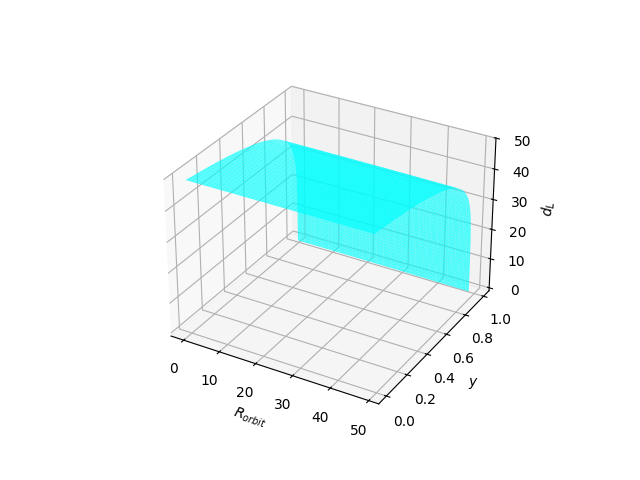

In [5]:
n = 50
R_orbit_array = onp.geomspace(20, 5000, n)
src_pos_array = onp.linspace(0.01, 0.99, n)
dL_array = onp.geomspace(0.1, 10, n)

R_orbit_mesh, src_pos_mesh, dL_mesh = onp.meshgrid(R_orbit_array, src_pos_array, dL_array, indexing='xy')
vol_1 = R_orbit_mesh ** 2 + src_pos_mesh ** 2 + dL_mesh ** 2
print(onp.max(vol_1), onp.min(vol_1))

verts, faces, _, _ = marching_cubes(vol_1, level=500)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
mesh = Poly3DCollection(verts[faces], alpha=0.7)
mesh.set_facecolor('cyan')
ax.add_collection3d(mesh)

# ax.set_xlim(20, 5000)
# ax.set_ylim(0.01, 0.99)
# ax.set_zlim(0.1, 10)

# ax.set_xscale('log')
# ax.set_zscale('log')

ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$d_L$')

plt.show()